<a href="https://colab.research.google.com/github/eshajain-123/csot-ml-astronomy/blob/main/week2_baseline_starter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:

import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", device)

Using: cuda


In [8]:
!mkdir -p ~/.kaggle
!echo "KGAT_5f9501c0011427d341b466ff0b47def7" > ~/.kaggle/access_token
!chmod 600 ~/.kaggle/access_token

In [9]:
!pip install -U kaggle
!kaggle datasets list -s galaxy-zoo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.8/132.8 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 230.0/230.0 kB 16.0 MB/s eta 0:00:00
  Attempting uninstall: kagglesdk
    Found existing installation: kagglesdk 0.1.23
    Uninstalling kagglesdk-0.1.23:
      Successfully uninstalled kagglesdk-0.1.23
  Attempting uninstall: kaggle
    Found existing installation: kaggle 2.0.2
    Uninstalling kaggle-2.0.2:
      Successfully uninstalled kaggle-2.0.2
ref                                       title                                                size  lastUpdated                 downloadCount  voteCount  usabilityRating  
----------------------------------------  ---------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
jaimetrickz/galaxy-zoo-2-images           Galaxy Zoo 2: Images                           3281862708  2021-01-26 16:25:27.667000           8765         34  0.9411765        
r

In [10]:
!kaggle datasets download -d jaimetrickz/galaxy-zoo-2-images

Dataset URL: https://www.kaggle.com/datasets/jaimetrickz/galaxy-zoo-2-images
License(s): Attribution 4.0 International (CC BY 4.0)
100% 3.06G/3.06G [00:38<00:00, 84.2MB/s]



In [11]:
from pathlib import Path

RAW_ROOT = Path("galaxy_raw")
IMAGES_DIR = RAW_ROOT / "images_gz2" / "images"
DATA_ROOT = Path("galaxy_data")

# RAW_ROOT.mkdir(exist_ok=True)
# IMAGES_DIR.mkdir(exist_ok=True)

In [12]:
!unzip -q -o galaxy-zoo-2-images.zip -d galaxy_raw

In [13]:
!wget -q -O galaxy_raw/gz2_hart16.csv.gz https://gz2hart.s3.amazonaws.com/gz2_hart16.csv.gz
!gunzip -f galaxy_raw/gz2_hart16.csv.gz

In [14]:
print(RAW_ROOT)
print(IMAGES_DIR)

jpgs = list(IMAGES_DIR.glob("*.jpg"))
print("Number of images:", len(jpgs))
print("First image:", jpgs[0])

galaxy_raw
galaxy_raw/images_gz2/images
Number of images: 243434
First image: galaxy_raw/images_gz2/images/67223.jpg


In [15]:
!ls galaxy_raw
!ls galaxy_raw/images_gz2 | head

gz2_filename_mapping.csv  gz2_hart16.csv  images_gz2
images


In [16]:
!ls galaxy_raw/images_gz2/images | head

100000.jpg
100001.jpg
100002.jpg
100003.jpg
100004.jpg
100005.jpg
100006.jpg
100007.jpg
100008.jpg
10000.jpg


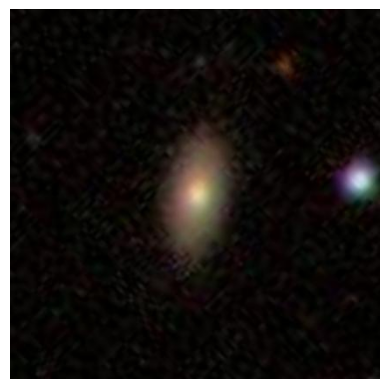

In [17]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(jpgs[0])

plt.imshow(img)
plt.axis("off")
plt.show()

In [18]:
def high_level_label(gz2_class):
    """Collapse detailed GZ2 codes (Sc2t, Ei, SBb2m, ...) to a few training buckets."""
    if not isinstance(gz2_class, str) or gz2_class == "A":
        return None
    if gz2_class.startswith("E"):
        return "elliptical"
    if gz2_class.startswith("SB"):
        return "spiral_barred"
    if gz2_class.startswith("S"):
        return "spiral"
    return None


def load_labeled_table(mapping_csv, labels_csv):
    mapping = pd.read_csv(mapping_csv)
    labels = pd.read_csv(labels_csv)
    if "dr7objid" in labels.columns:
        labels = labels.rename(columns={"dr7objid": "objid"})
    df = mapping.merge(labels[["objid", "gz2_class"]], on="objid", how="inner")
    df["label"] = df["gz2_class"].map(high_level_label)
    return df.dropna(subset=["label"]).reset_index(drop=True)


def _link_image(src, dst):
    if dst.exists():
        return False
    dst.parent.mkdir(parents=True, exist_ok=True)
    try:
        os.symlink(Path(src).resolve(), dst)
    except OSError:
        import shutil
        shutil.copy2(src, dst)
    return True


def build_split_imagefolder_layout(images_dir, df, out_root, per_class=200,
                                   train_frac=0.70, val_frac=0.15, test_frac=0.15, seed=42):
    images_dir, out_root = Path(images_dir), Path(out_root)
    for label in sorted(df["label"].unique()):
        rows = df[df["label"] == label].sample(frac=1, random_state=seed)
        if len(rows) > per_class:
            rows = rows.head(per_class)
        n = len(rows)
        n_train, n_val = int(train_frac * n), int(val_frac * n)
        splits = {
            "train": rows.iloc[:n_train],
            "val": rows.iloc[n_train:n_train + n_val],
            "test": rows.iloc[n_train + n_val:],
        }
        for split_name, split_rows in splits.items():
            for _, row in split_rows.iterrows():
                src = images_dir / f"{int(row.asset_id)}.jpg"
                dst = out_root / split_name / label / f"{int(row.asset_id)}.jpg"
                if src.exists():
                    _link_image(src, dst)


PER_CLASS = 200  # bump up (e.g. 2000) once everything works

df = load_labeled_table(RAW_ROOT / "gz2_filename_mapping.csv", RAW_ROOT / "gz2_hart16.csv")
build_split_imagefolder_layout(IMAGES_DIR, df, DATA_ROOT, per_class=PER_CLASS)
print(df["label"].value_counts())

label
elliptical       97670
spiral           95849
spiral_barred    45581
Name: count, dtype: int64


In [19]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

train_ds = ImageFolder(root=DATA_ROOT / "train", transform=transform)
val_ds   = ImageFolder(root=DATA_ROOT / "val",   transform=transform)
test_ds  = ImageFolder(root=DATA_ROOT / "test",  transform=transform)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

num_classes = len(train_ds.classes)
print("classes      :", train_ds.classes)
print("class_to_idx :", train_ds.class_to_idx)
print("num_classes  :", num_classes)


classes      : ['elliptical', 'spiral', 'spiral_barred']
class_to_idx : {'elliptical': 0, 'spiral': 1, 'spiral_barred': 2}
num_classes  : 3


In [20]:
dataset = ImageFolder(root=DATA_ROOT, transform=transform)
print("num images   :", len(dataset))
print("classes      :", dataset.classes)
print("class_to_idx :", dataset.class_to_idx)

num images   : 600
classes      : ['test', 'train', 'val']
class_to_idx : {'test': 0, 'train': 1, 'val': 2}


In [21]:
image, label = dataset[0]
print("shape :", image.shape)   # torch.Size([3, 64, 64])
print("dtype :", image.dtype)   # torch.float32
print("label :", label, "->", dataset.classes[label])

shape : torch.Size([3, 64, 64])
dtype : torch.float32
label : 0 -> test


In [22]:
loader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)

images, labels = next(iter(loader))
print("images:", images.shape)
print("labels:", labels.shape)

images: torch.Size([32, 3, 64, 64])
labels: torch.Size([32])


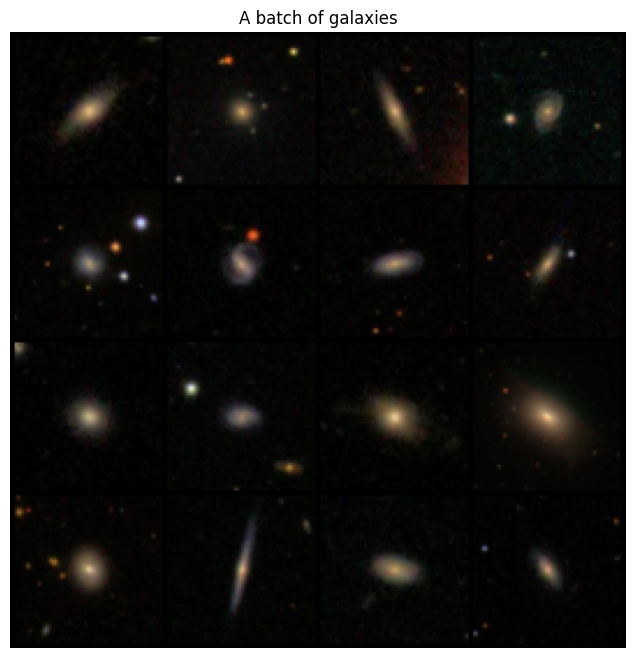

Labels: ['train', 'train', 'test', 'train', 'train', 'test', 'test', 'val', 'train', 'train', 'test', 'train', 'train', 'train', 'train', 'train']


In [23]:
import torchvision
images_show = images * 0.5 + 0.5
grid = torchvision.utils.make_grid(images_show[:16], nrow=4)

plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
plt.axis("off")
plt.title("A batch of galaxies")
plt.show()

print("Labels:", [dataset.classes[i] for i in labels[:16].tolist()])

In [24]:
print("train_loader exists?", "train_loader" in globals())
print("test_loader exists?", "test_loader" in globals())

train_loader exists? True
test_loader exists? True


In [25]:
def loader_to_numpy(loader):
  x_parts = []
  y_parts = []

  for images, labels in loader:
    flat = images.flatten(start_dim=1)
    x_parts.append(flat.numpy())
    y_parts.append(labels.numpy())

  x = np.concatenate(x_parts)
  y = np.concatenate(y_parts)

  return x, y

x_train, y_train = loader_to_numpy(train_loader)
x_test, y_test = loader_to_numpy(test_loader)

print("x_train:", x_train.shape, "y_train:", y_train.shape)
print("x_test :", x_test.shape,  "y_test :", y_test.shape)
assert x_train.shape[1] == 3 * 64 * 64

x_train: (420, 12288) y_train: (420,)
x_test : (90, 12288) y_test : (90,)


In [26]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(x_train, y_train)
y_pred = dummy.predict(x_test)
accuracy_score(y_test, y_pred)

0.3333333333333333

In [29]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train, y_train)
y_pred = knn.predict(x_test)

accuracy_score(y_test, y_pred)

0.4111111111111111

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(x_train, y_train)
y_pred = log_reg.predict(x_test)

accuracy_score(y_test, y_pred)

0.4666666666666667

In [33]:
random_acc = 1 / num_classes
majority_acc = accuracy_score(y_test, dummy.predict(x_test))
knn_acc = accuracy_score(y_test, knn.predict(x_test))
logreg_acc = accuracy_score(y_test, log_reg.predict(x_test))

print("Model comparison:")
print("------------------")
print(f"Random baseline     : {random_acc:.3f}")
print(f"Majority baseline   : {majority_acc:.3f}")
print(f"KNN                 : {knn_acc:.3f}")
print(f"Logistic Regression : {logreg_acc:.3f}")

baseline = max(random_acc, majority_acc, knn_acc, logreg_acc)
print("\nWeek 3 must beat:", baseline)


Model comparison:
------------------
Random baseline     : 0.333
Majority baseline   : 0.333
KNN                 : 0.411
Logistic Regression : 0.467

Week 3 must beat: 0.4666666666666667
